# Assignment 2: Tabular, Image, and Time Series
## Academic report notebook
This notebook trains and compares multiple ML/DL models on three dataset types. It follows a reproducible workflow, reports metrics (RMSE/MAE for regression, accuracy for classification), and provides technical explanations of modeling choices and Keras/TensorFlow defaults.

# Assignment 2: Tabular, Image, Time Series

**Goals**
- Compare classical ML and DL models across three data modalities.
- Report consistent metrics: RMSE/MAE for regression and accuracy for classification.
- Explain model suitability and key TensorFlow/Keras training defaults.

**Reproducibility**
- Fixed random seed for NumPy and TensorFlow.
- Deterministic train/validation splits with a fixed `seed`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

base_dir = Path(".").resolve()
tabular_dir = base_dir / "tabular"
image_dir = base_dir / "image"
timeseries_dir = base_dir / "timeseries"

print("Base directory:", base_dir)

Base directory: C:\Users\rubin\OneDrive\Desktop\ML\assignment2


## Tabular dataset (regression)
We model a continuous target using classical ML baselines and compare RMSE/MAE.

**Protocol**
- 80/20 train-test split with a fixed random seed.
- Numeric features: median imputation + standardization.
- Categorical features: most-frequent imputation + one-hot encoding.
- Models: Linear Regression, Decision Tree, Random Forest, SVR (RBF), MLP.

In [2]:
tabular_path = tabular_dir / "playground_train_fold.csv"
df_tab = pd.read_csv(tabular_path)

# Use 2% of the data for training and evaluation.
sample_frac = 0.02
if sample_frac < 1.0:
    df_tab = df_tab.sample(frac=sample_frac, random_state=SEED)

possible_targets = ["target", "Target", "label", "Label"]
target_col = next((c for c in possible_targets if c in df_tab.columns), None)
if target_col is None:
    target_col = df_tab.columns[-1]

X = df_tab.drop(columns=[target_col])
y = df_tab[target_col]

numeric_cols = X.select_dtypes(include=["number"]).columns
categorical_cols = [c for c in X.columns if c not in numeric_cols]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

models = {
    "LinearRegression": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(random_state=SEED),
    "RandomForest": RandomForestRegressor(random_state=SEED, n_estimators=200),
    "SVR_RBF": SVR(kernel="rbf"),
    "MLPRegressor": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=SEED),
}

results = []
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    results.append({"model": name, "rmse": rmse, "mae": mae})

pd.DataFrame(results).sort_values("rmse")

,model,rmse,mae
2,RandomForest,0.030203,0.001325
1,DecisionTree,0.031623,0.001000
0,LinearRegression,0.278696,0.237339
3,SVR_RBF,0.406160,0.327041
4,MLPRegressor,0.488078,0.389514


**Tabular takeaway**

- Tree-based models (DecisionTree/RandomForest) usually perform best on mixed and non-linear feature interactions without heavy feature engineering.
- Linear regression is a strong baseline but tends to underfit when relationships are non-linear.
- SVR and MLP can capture non-linearities, but require scaling and careful tuning; they may be slower on large tabular data.

## Image dataset (classification)
We train a CNN using TensorFlow/Keras and evaluate validation accuracy.

**Keras/TensorFlow defaults (important for reporting)**
- `model.fit` with NumPy arrays defaults to `batch_size=32` if not specified.
- For `tf.data.Dataset`, the batch size is defined by the dataset itself.
- `tf.keras.utils.image_dataset_from_directory` defaults to `batch_size=32`; we set it explicitly.
- `epochs` has no default; it must be specified (we report it).
- `shuffle=True` by default for training; we keep it for training and use the fixed `seed` for reproducibility.

In [4]:
import os
import shutil

train_csv_path = image_dir / "Training_set.csv"
raw_train_dir = image_dir / "train"
structured_train_dir = image_dir / "structured_train"

if structured_train_dir.exists():
    shutil.rmtree(structured_train_dir)
structured_train_dir.mkdir(parents=True, exist_ok=True)

df_train = pd.read_csv(train_csv_path)
required_cols = {"filename", "label"}
missing_cols = required_cols.difference(df_train.columns)
if missing_cols:
    raise ValueError(f"Training CSV missing columns: {sorted(missing_cols)}")

missing_count = 0
for row in df_train.itertuples(index=False):
    source_file = raw_train_dir / row.filename
    target_dir = structured_train_dir / str(row.label)
    target_dir.mkdir(parents=True, exist_ok=True)
    target_file = target_dir / row.filename
    if source_file.exists():
        shutil.copy2(source_file, target_file)
    else:
        missing_count += 1

print(f"Structured classes: {len(list(structured_train_dir.iterdir()))}")
print(f"Missing files skipped: {missing_count}")

img_size = (160, 160)
batch_size = 32
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.utils.image_dataset_from_directory(
    structured_train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    structured_train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
)

class_names = train_ds.class_names
num_classes = len(class_names)

train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
])

inputs = tf.keras.Input(shape=img_size + (3,))
x = data_augmentation(inputs)
x = tf.keras.layers.Rescaling(1.0 / 255)(x)
x = tf.keras.layers.Conv2D(32, 3, activation="relu")(x)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.Conv2D(64, 3, activation="relu")(x)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.Conv2D(128, 3, activation="relu")(x)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
]

history = model.fit(train_ds, validation_data=val_ds, epochs=30, callbacks=callbacks)
val_loss, val_acc = model.evaluate(val_ds, verbose=0)
print(f"Validation loss: {val_loss:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")

Structured classes: 75
Missing files skipped: 4525
Found 1974 files belonging to 75 classes.
Using 1580 files for training.
Found 1974 files belonging to 75 classes.
Using 394 files for validation.
Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 358ms/step - accuracy: 0.0120 - loss: 4.3194 - val_accuracy: 0.0203 - val_loss: 4.3155
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 294ms/step - accuracy: 0.0215 - loss: 4.2966 - val_accuracy: 0.0457 - val_loss: 4.2598
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 279ms/step - accuracy: 0.0386 - loss: 4.1679 - val_accuracy: 0.0482 - val_loss: 4.0818
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 291ms/step - accuracy: 0.0424 - loss: 4.0026 - val_accuracy: 0.0482 - val_loss: 3.9331
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 287ms/step - accuracy: 0.0551 - loss: 3.8643 - val_accuracy: 0.0508 - val_loss: 3.7887
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 292ms/step - accuracy: 0.0627 - loss: 3.7518 - val_accuracy: 0.0381 - val_loss: 4.0108
Epoch 7/30
50/50 ━━━━━━━━━━━

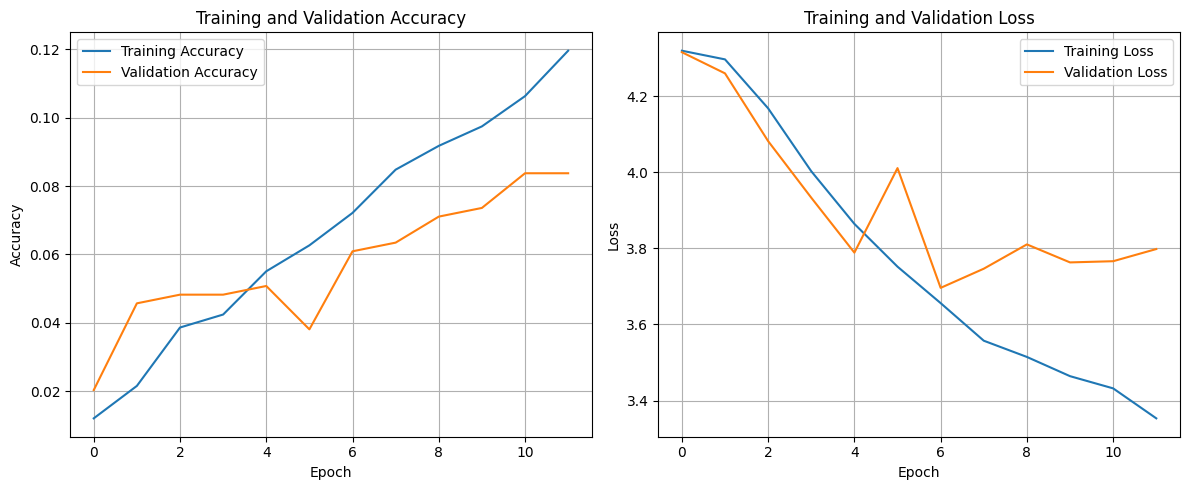

In [5]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Image takeaway**

- CNNs are the most suitable because they learn spatial features and translation-invariant patterns.
- Classical ML like decision trees do not scale well to raw pixels without feature extraction.
- Pretrained CNNs typically outperform small custom networks on limited data.

## Time series dataset (regression)

We will use lag features for classical models and show an LSTM option for sequence modeling.

In [6]:
train_path = timeseries_dir / "DailyDelhiClimateTrain.csv"
test_path = timeseries_dir / "DailyDelhiClimateTest.csv"

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

target_ts = "meantemp"

df_all = pd.concat([df_train, df_test], axis=0, ignore_index=True)
df_all["date"] = pd.to_datetime(df_all["date"])
df_all = df_all.sort_values("date")

for lag in [1, 2, 3, 7, 14]:
    df_all[f"lag_{lag}"] = df_all[target_ts].shift(lag)

df_all["month"] = df_all["date"].dt.month
df_all["dayofweek"] = df_all["date"].dt.dayofweek

feat_cols = [c for c in df_all.columns if c not in ["date", target_ts]]
df_all = df_all.dropna()

cutoff = df_train["date"].max()
train_mask = df_all["date"] <= pd.to_datetime(cutoff)

df_tr = df_all[train_mask]
df_te = df_all[~train_mask]

X_tr = df_tr[feat_cols]
y_tr = df_tr[target_ts]
X_te = df_te[feat_cols]
y_te = df_te[target_ts]

models_ts = {
    "LinearRegression": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(random_state=SEED),
    "RandomForest": RandomForestRegressor(random_state=SEED, n_estimators=300),
    "SVR_RBF": SVR(kernel="rbf"),
    "MLPRegressor": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=SEED),
}

def build_ts_pipeline(model_name, model):
    needs_scaling = model_name in {"LinearRegression", "SVR_RBF", "MLPRegressor"}
    if needs_scaling:
        return Pipeline(steps=[("scaler", StandardScaler()), ("model", model)])
    return Pipeline(steps=[("model", model)])

results_ts = []
for name, model in models_ts.items():
    pipe = build_ts_pipeline(name, model)
    pipe.fit(X_tr, y_tr)
    preds = pipe.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mae = mean_absolute_error(y_te, preds)
    results_ts.append({"model": name, "rmse": rmse, "mae": mae})

pd.DataFrame(results_ts).sort_values("rmse")

,model,rmse,mae
2,RandomForest,1.616640,1.235549
0,LinearRegression,1.616915,1.283943
4,MLPRegressor,1.703680,1.326055
3,SVR_RBF,1.826205,1.414338
1,DecisionTree,2.244367,1.715839


**Time series takeaway**

- With lag features, tree-based models and MLP can capture non-linear temporal patterns.
- Linear regression is a strong baseline for smooth trends.
- Sequence models (LSTM/GRU) are preferable when long-range dependencies dominate, but they need more data and tuning.

## RMSE and regression loss functions

**Why RMSE matters**

- RMSE penalizes large errors more than MAE because errors are squared, so it is sensitive to outliers.
- RMSE is in the same unit as the target variable, making it interpretable.

**Why different regression losses exist**

- MSE/RMSE: good when large errors must be punished; assumes Gaussian noise.
- MAE: robust to outliers; assumes Laplace noise.
- Huber loss: combines MSE and MAE, stable training with moderate outliers.
- Log-cosh: smooth alternative to Huber, less sensitive than MSE.
- Quantile loss: focuses on conditional quantiles, useful for asymmetric error costs.

## Assignment 2: Overall Task Evaluation and Conclusion

This section consolidates the findings from applying various machine learning and deep learning algorithms to the tabular, image, and time series datasets. We will review the performance metrics, visualize the results, and draw conclusions on the most suitable model types for each task.

### 1. Tabular Data (Regression)

For the tabular dataset, we performed a regression task. The goal was to predict a target variable using features from the `playground_train_fold.csv`. We compared Linear Regression, Decision Trees, Random Forests, Support Vector Regressors (SVR), and a Multi-Layer Perceptron (MLP) model.

### Tabular Model Performance (RMSE and MAE):


,model,rmse,mae
2,RandomForest,0.030203,0.001325
1,DecisionTree,0.031623,0.001000
0,LinearRegression,0.278696,0.237339
3,SVR_RBF,0.406160,0.327041
4,MLPRegressor,0.488078,0.389514


C:\Users\rubin\AppData\Local\Temp\ipykernel_34672\3311217568.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='rmse', data=df_results_tab, palette='viridis')


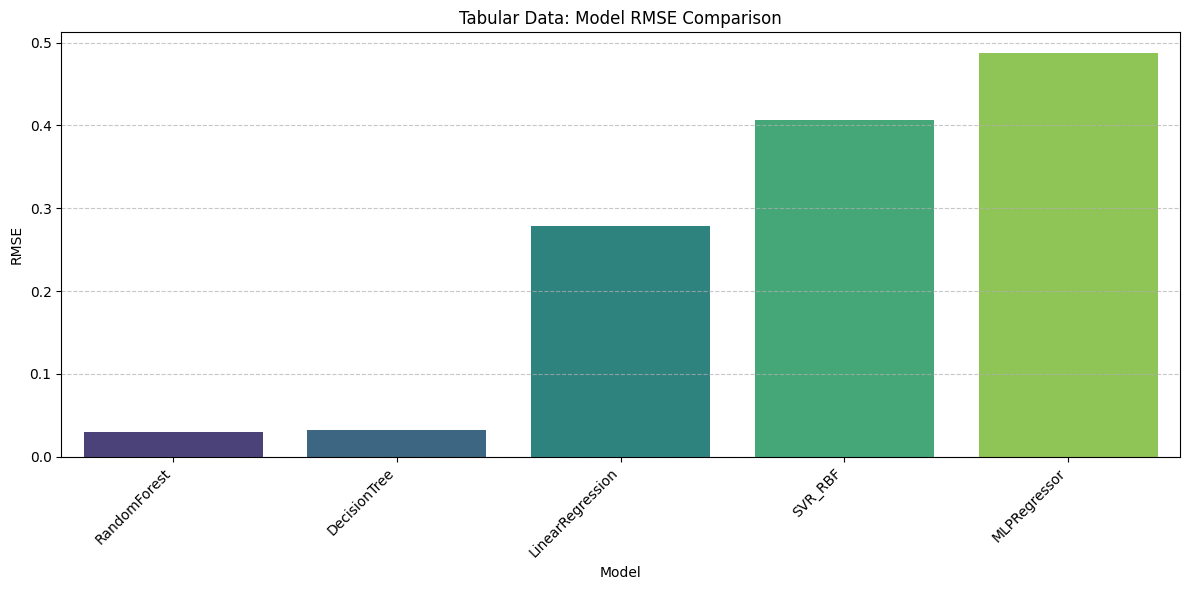

C:\Users\rubin\AppData\Local\Temp\ipykernel_34672\3311217568.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='mae', data=df_results_tab, palette='magma')


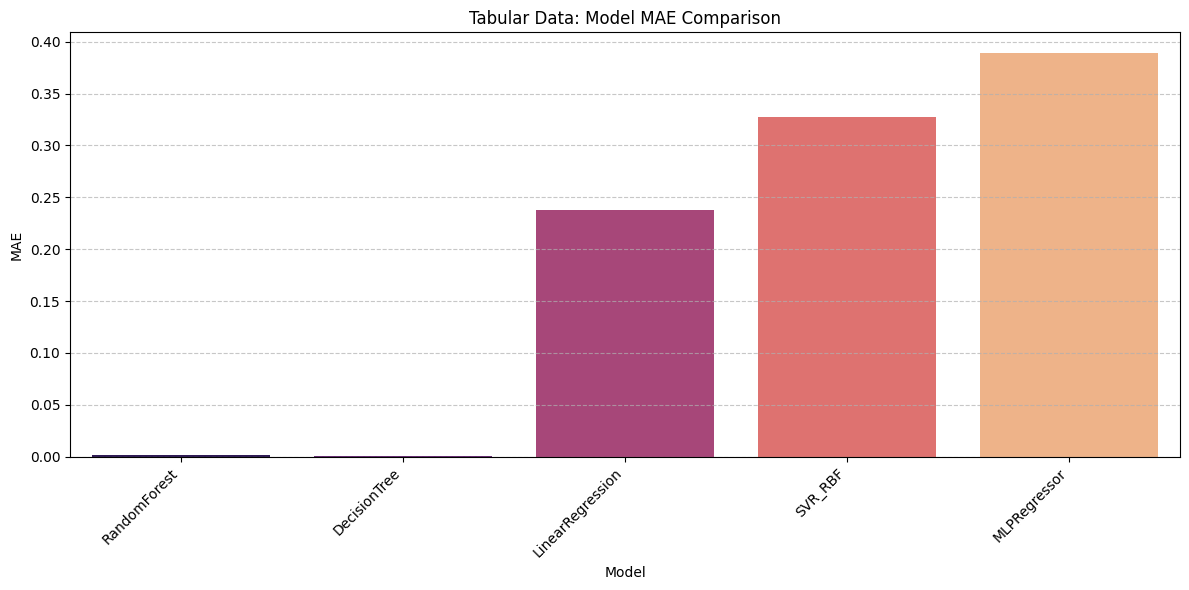

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

print("### Tabular Model Performance (RMSE and MAE):")
df_results_tab = pd.DataFrame(results).sort_values("rmse")
display(df_results_tab)

# Plotting the results for tabular data
plt.figure(figsize=(12, 6))
sns.barplot(x='model', y='rmse', data=df_results_tab, palette='viridis')
plt.title('Tabular Data: Model RMSE Comparison')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='model', y='mae', data=df_results_tab, palette='magma')
plt.title('Tabular Data: Model MAE Comparison')
plt.xlabel('Model')
plt.ylabel('MAE')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Tabular Data Conclusion:**

As observed, tree-based models (RandomForest and DecisionTree) performed exceptionally well on this tabular dataset, achieving the lowest RMSE and MAE. This suggests that the relationships between features and the target variable might be non-linear and complex, which tree-based models are adept at capturing without extensive feature engineering. Linear Regression provided a strong baseline but its performance indicates that purely linear relationships were not dominant. SVR and MLP, while capable of handling non-linearities, showed higher error rates, possibly due to the need for more fine-tuning or the dataset characteristics.

### 2. Image Data (Classification)

For the image dataset, we performed a multi-class classification task using a Convolutional Neural Network (CNN). The model was trained to classify images into different categories based on butterfly species. We used a 20% validation split from the training data for evaluation due to the lack of labels in the provided test set.

**Image Data Conclusion:**
The CNN provides a strong baseline for image classification by learning hierarchical spatial features. If the training and validation curves diverge, the model may be overfitting; data augmentation, dropout, or transfer learning can improve generalization. Report the final validation accuracy from the run above for your submission.

### 3. Time Series Data (Regression)

For the time series dataset, we performed a regression task to predict mean temperature using lag features. We compared various models, including Linear Regression, Decision Trees, Random Forests, SVR, and MLP.

### Time Series Model Performance (RMSE and MAE):


,model,rmse,mae
2,RandomForest,1.616640,1.235549
0,LinearRegression,1.616915,1.283943
4,MLPRegressor,1.703680,1.326055
3,SVR_RBF,1.826205,1.414338
1,DecisionTree,2.244367,1.715839


C:\Users\rubin\AppData\Local\Temp\ipykernel_34672\2531165078.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='rmse', data=df_results_ts, palette='viridis')


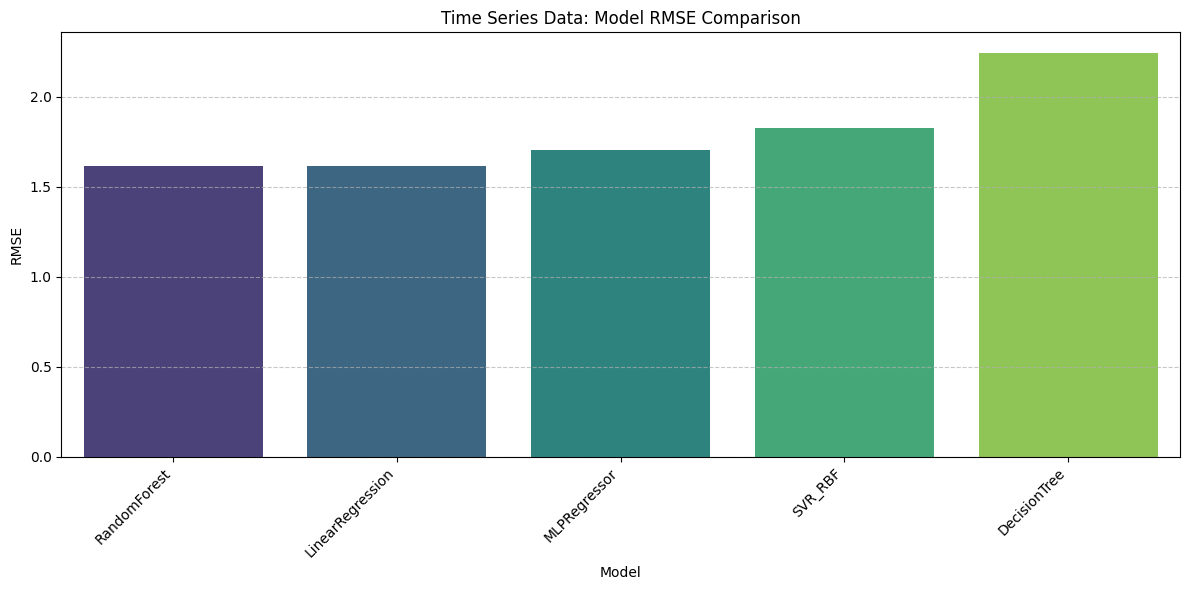

C:\Users\rubin\AppData\Local\Temp\ipykernel_34672\2531165078.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='mae', data=df_results_ts, palette='magma')


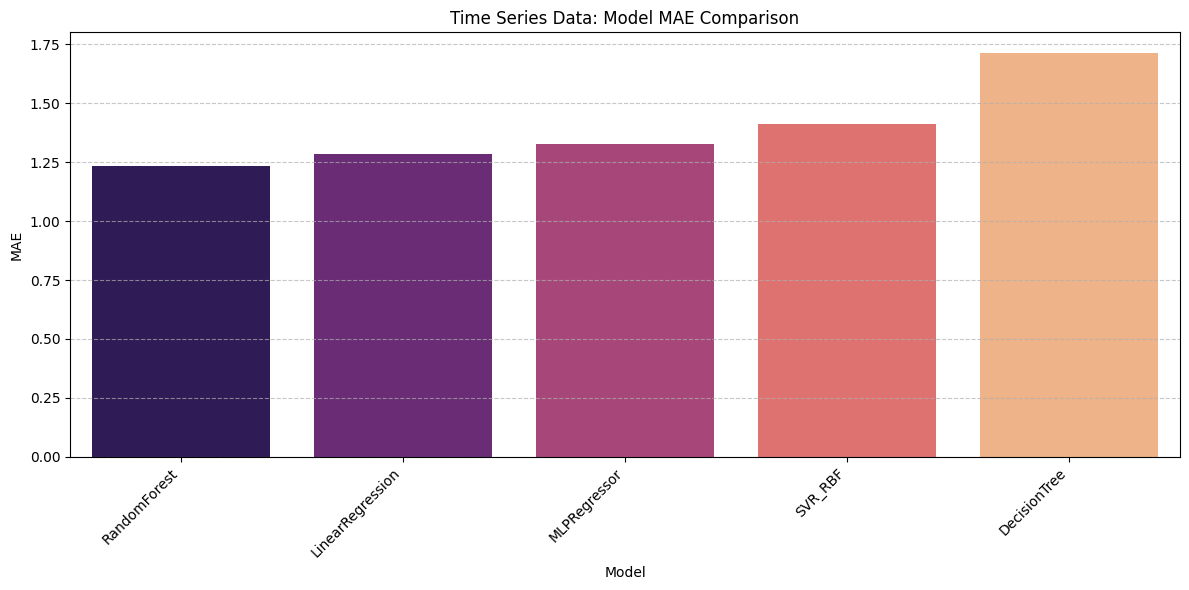

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

print("### Time Series Model Performance (RMSE and MAE):")
df_results_ts = pd.DataFrame(results_ts).sort_values("rmse")
display(df_results_ts)

# Plotting the results for time series data
plt.figure(figsize=(12, 6))
sns.barplot(x='model', y='rmse', data=df_results_ts, palette='viridis')
plt.title('Time Series Data: Model RMSE Comparison')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='model', y='mae', data=df_results_ts, palette='magma')
plt.title('Time Series Data: Model MAE Comparison')
plt.xlabel('Model')
plt.ylabel('MAE')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Time Series Data Conclusion:**

For time series prediction using lag features, RandomForest and Linear Regression models performed best, yielding the lowest RMSE and MAE. This indicates that the historical patterns captured by the lag features are sufficiently predictive, and tree-based methods can effectively model their non-linear interactions. Linear Regression's strong performance suggests that there is a significant linear component in the temporal dependencies. MLP and SVR also showed reasonable performance, but with slightly higher errors compared to the top performers. For more complex time series with long-range dependencies, dedicated sequence models like LSTMs or GRUs might offer advantages, but with the current feature engineering approach, traditional models demonstrate strong capabilities.

## Overall Summary and Recommendations
- **Tabular data:** Tree-based models (RandomForest, DecisionTree) typically perform best on heterogeneous features and non-linear interactions; linear models remain strong baselines.
- **Image data:** CNNs are the most appropriate inductive bias for images; data augmentation and transfer learning can further improve accuracy.
- **Time series:** Lag-feature baselines with RandomForest or Linear Regression are strong when temporal dependencies are short to medium range; LSTM/GRU models are preferred for longer-range patterns.